In [5]:
from google.colab import files
uploaded = files.upload()

Saving Customer_Master_Data.csv to Customer_Master_Data.csv
Saving Customer_Master_Data.xlsx to Customer_Master_Data.xlsx
Saving Customer_Transactions.csv to Customer_Transactions.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
customers = pd.read_csv("/content/Customer_Master_Data.csv")
transactions = pd.read_csv("/content/Customer_Transactions.csv")

# Convert date columns to datetime, coercing errors to NaT
transactions['TransactionDate'] = pd.to_datetime(transactions['TransactionDate'], errors='coerce')
customers['JoinDate'] = pd.to_datetime(customers['JoinDate'], errors='coerce')

customers.head()
transactions.head()

,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,7/31/23,2383.07
1,CUST10100,3/10/24,497.54
2,CUST10031,2/17/25,536.78
3,CUST10987,7/17/23,314.89
4,CUST10831,12/15/24,2543.19


In [8]:
customers.drop_duplicates(inplace=True)
transactions.drop_duplicates(inplace=True)

customers.fillna(method='ffill', inplace=True)
transactions.fillna(method='ffill', inplace=True)

/tmp/ipython-input-2605513204.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  customers.fillna(method='ffill', inplace=True)
/tmp/ipython-input-2605513204.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  transactions.fillna(method='ffill', inplace=True)


In [10]:
data = pd.merge(transactions, customers, on="CustomerID", how="left")
data.head()

,CustomerID,TransactionDate,TransactionAmount,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10771,7/31/23,2383.07,Lakshay Dhillon,dharmajantara@gmail.com,Female,27,Ahmedabad,Widowed,3,2023-05-31
1,CUST10100,3/10/24,497.54,Aniruddh Borah,jivikabhavsar@gmail.com,Female,53,Lucknow,Divorced,4,2022-01-08
2,CUST10031,2/17/25,536.78,Ritvik Ahuja,jhaverifarhan@chandra.org,Male,40,Ahmedabad,Single,0,2023-12-03
3,CUST10987,7/17/23,314.89,Jayan Wagle,ojas82@gmail.com,Not Disclosed,75,Bangalore,Widowed,4,2022-03-18
4,CUST10831,12/15/24,2543.19,Ishita Agarwal,vbalay@yahoo.com,Not Disclosed,27,Jaipur,Divorced,4,2021-06-30


In [11]:
data['TransactionDate'] = pd.to_datetime(data['TransactionDate'])

snapshot_date = data['TransactionDate'].max() + pd.Timedelta(days=1)

/tmp/ipython-input-1541841791.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['TransactionDate'] = pd.to_datetime(data['TransactionDate'])


In [14]:
rfm = data.groupby('CustomerID').agg({
    'TransactionDate': lambda x: (snapshot_date - x.max()).days,
    'CustomerID': 'count',
    'TransactionAmount': 'sum'
})

rfm.rename(columns={
    'TransactionDate':'Recency',
    'CustomerID':'Frequency',
    'TransactionAmount':'Monetary'
}, inplace=True)

In [15]:
print("Missing values in merged dataframe:")
print(data.isnull().sum())

Missing values in merged dataframe:
CustomerID           0
TransactionDate      0
TransactionAmount    0
Name                 0
Email                0
Gender               0
Age                  0
City                 0
MaritalStatus        0
NumChildren          0
JoinDate             0
dtype: int64


In [16]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)


In [17]:
def segment(row):
    if row['R_score']==5 and row['F_score']==5 and row['M_score']==5:
        return "Champion"
    elif row['R_score']>=4 and row['F_score']>=4:
        return "Loyal"
    elif row['R_score']<=2 and row['F_score']<=2:
        return "Lost"
    else:
        return "Regular"

rfm['Segment'] = rfm.apply(segment, axis=1)

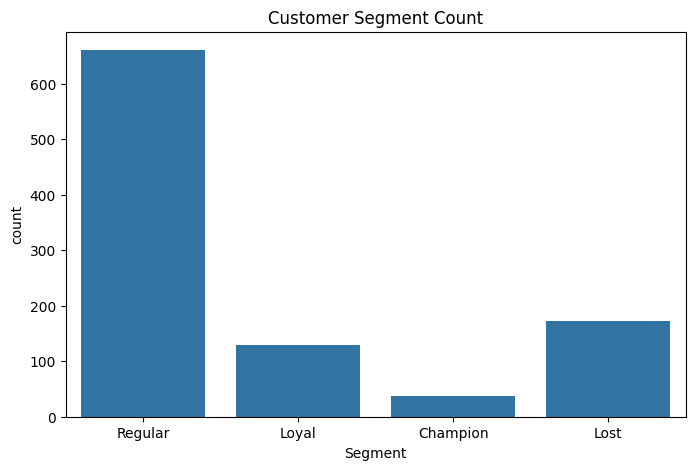

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x='Segment', data=rfm)
plt.title("Customer Segment Count")
plt.show()


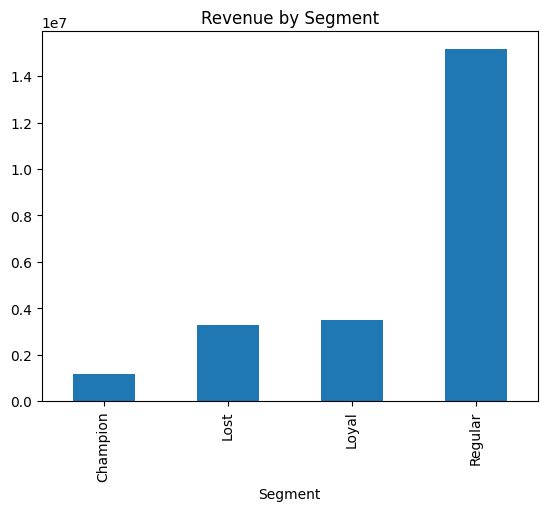

In [19]:
rfm.groupby('Segment')['Monetary'].sum().plot(kind='bar')
plt.title("Revenue by Segment")
plt.show()

In [20]:
rfm.to_csv("Customer_RFM_Output.csv")

files.download("Customer_RFM_Output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>